# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Ler o arquivo .csv e dar um resumo
df = pd.read_csv("precos_carros_brasil.csv")

df = df.dropna(how='all')

df = df.drop_duplicates()

In [3]:
# Relacionar as colunas da base de dados
colunas_numericas = [col for col in df.columns if df[col].dtype != 'str']

# 1. engine_size: Troca a vírgula para ponto e transforma para tipo float
engine_size_num = df['engine_size'].astype(str).str.replace(',', '.').str.strip()
engine_size_num = pd.to_numeric(engine_size_num, errors='coerce')

# 2. gear: Fazer label encoding da variável gear
gear_num = df['gear'].map({'manual': 0, 'automatic': 1})

# 3. fuel: One-Hot Encoding
fuel_dummies = pd.get_dummies(df['fuel'], prefix='fuel', dtype=int, drop_first=False)

# 4. brand: Label Encoding de marcas para código númerico
brand_encoded = pd.DataFrame({'brand_encoded':df['brand'].astype('category').cat.codes})

# Variáveis independentes
features = ['year_of_reference', 'year_model', 'engine_size',
            'gear', 'brand_encoded',
            'fuel_Gasoline', 'fuel_Alcohol', 'fuel_Diesel']

target = 'avg_price_brl'

# Remove linhas com NaN nas features
df_ml = pd.concat([df[colunas_numericas], engine_size_num, gear_num, fuel_dummies, brand_encoded],axis=1)
df_ml = df_ml.dropna()

X = df_ml[features]
#X_original = df_ml[colunas_numericas].drop([target], axis=1)
y = df_ml[target]

# 2. Separar treino e teste

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Definir modelos

In [5]:
models = {

    "LinearRegression": LinearRegression(),
    #"Ridge": Ridge(),
    #"Lasso": Lasso(),

    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    "GradientBoosting": GradientBoostingRegressor(),

    #"SVR": SVR()
}

# 4. Treinar modelos

In [6]:
trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    trained_models[name] = model

# 5. Calcular Permutation Importance

In [7]:
importance_results = {}

for name, model in trained_models.items():

    result = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=20,
        random_state=42,
        n_jobs=-1
    )

    importance_results[name] = result.importances_mean

# 6. Criar DataFrame comparativo

In [8]:
importance_df = pd.DataFrame(
    importance_results,
    index=X.columns
)

importance_df

,LinearRegression,RandomForest,GradientBoosting
year_of_reference,0.013263,0.023973,0.018936
year_model,0.714184,1.497877,1.274751
engine_size,0.444246,1.778490,1.259036
gear,0.017262,0.063181,0.037689
brand_encoded,0.002481,0.085018,0.019588
fuel_Gasoline,0.023699,0.028212,0.004868
fuel_Alcohol,0.000693,0.000014,0.000000
fuel_Diesel,0.005242,0.130775,0.048119


# 7. Heatmap comparativo

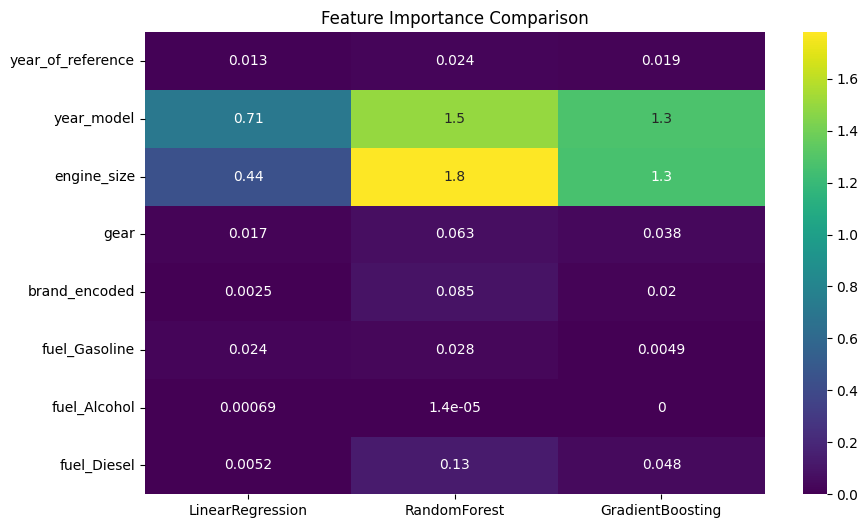

In [9]:
plt.figure(figsize=(10,6))

sns.heatmap(
    importance_df,
    cmap="viridis",
    annot=True
)

plt.title("Feature Importance Comparison")
plt.show()

# 8. Ranking médio de importância

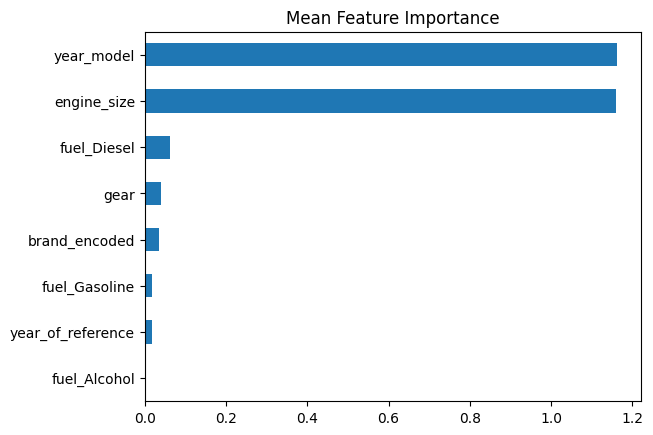

In [10]:
importance_df["mean_importance"] = importance_df.mean(axis=1)

importance_df.sort_values(
    "mean_importance",
    ascending=True
)["mean_importance"].plot.barh()

plt.title("Mean Feature Importance")
plt.show()

# 9. Visualizar importância por modelo

In [ ]:
for model in importance_df.columns[:-1]:

    importance_df[model].sort_values().plot.barh()
    plt.title(model)
    plt.show()